In [1]:
import sys
from pathlib import Path
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

In [2]:
# Ручная реализация AdaGrad
def adagrad(
    obj: Callable[[np.ndarray], np.float64],
    grad: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    lr: np.float64 = 1e-2,
    eps: np.float64 = 1e-8,
    tolerance: np.float64 = 1e-6,
    max_iter: int = 1000
) -> list[np.ndarray]:
    
    x = x0.astype(np.float64).copy()
    history = [x.copy()]
    # Кумулятивный исорический градиент (квадраты градиентов)
    G = np.zeros_like(x, dtype=np.float64)
    for k in range(max_iter):
        grad_x = grad(x)
        if np.linalg.norm(grad_x) < tolerance:
            break
        # Аккумулируем квадраты текущего градиента
        G += grad_x ** 2
        # адаптивный шаг покоординатно
        x -= (lr / (np.sqrt(G) + eps)) * grad_x
        history.append(x.copy())
    return history

In [3]:
# Ручная реализация AdamW
def adamw(
    obj: Callable[[np.ndarray], np.float64],
    grad: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    lr: np.float64 = 1e-3,
    beta1: np.float64 = 0.9,
    beta2: np.float64 = 0.999,
    eps: np.float64 = 1e-8,
    weight_decay: np.float64 = 1e-2,
    tolerance: np.float64 = 1e-6,
    max_iter: int = 1000
) -> list[np.ndarray]:

    x = x0.astype(np.float64).copy()
    history = [x.copy()]
    # первый (m) и второй (v) моменты
    m = np.zeros_like(x, dtype=np.float64)
    v = np.zeros_like(x, dtype=np.float64)
    for k in range(1, max_iter + 1):
        grad_x = grad(x)
        if np.linalg.norm(grad_x) < tolerance:
            break
        # Обновление моментов (экспоненциальное сглаживание)
        m = beta1 * m + (1.0 - beta1) * grad_x
        v = beta2 * v + (1.0 - beta2) * (grad_x ** 2)
        # Коррекция смещения (bias correction) для первых итераций
        m_hat = m / (1.0 - beta1 ** k)
        v_hat = v / (1.0 - beta2 ** k)
        # обновление весов с изолированным затуханием (Decoupled Weight Decay)
        # (В отличие от Adam, регуляризация применяется в обход векторов m и v)
        x -= lr * weight_decay * x + (lr / (np.sqrt(v_hat) + eps)) * m_hat
        history.append(x.copy())
    return history

# Онлайн обучение. Постановка задачи


На каждом шаге $t = 1, 2, \dots$:
1) Алгоритм выбирает вектор весов $w_t \in \mathbb{R}^d$.
2) "Природа" выдает объект признаков $X_t$ и истинный таргет $y_t$, формируя локальную функцию потерь $\mathcal{L}_t(w)$. Для линейной регрессии: $\mathcal{L}_t(w) = \frac{1}{2} (X_t w - y_t)^2$.
3) Алгоритм несет потери $\mathcal{L}_t(w_t)$ и вычисляет стохастический градиент(где $B$ - размер батча на шаге $t$):
$$g_t = \nabla \mathcal{L}_t(w_t) = \frac{1}{B} X_t^\top (X_t w_t - y_t)$$
4) Цель оптимизатора - выбрать последовательность $\{w_t\}$, минимизирующую регрет за $T$ шагов относительно наилучшего статического вектора весов $w^*$:$$R_T = \sum_{t=1}^T \mathcal{L}_t(w_t) - \min_{w^*} \sum_{t=1}^T \mathcal{L}_t(w^*)$$

## AdaGrad
Адаптирует скорость обучения индивидуально для каждого признака (координаты вектора весов) на основе исторической изменчивости градиента.
На шаге $t$ для каждой координаты $i \in \{1, \dots, d\}$ аккумулируется сумма квадратов всех прошлых градиентов:
$$G_{t, i} = G_{t-1, i} + g_{t, i}^2$$
В векторной форме через покоординатное умножение $\odot$:
$$G_t = G_{t-1} + g_t \odot g_t$$
Правило обновления весов:$$w_{t+1} = w_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t$$
Где $\eta$ - базовый learning rate, а $\epsilon > 0$ - параметр сглаживания, предотвращающий деление на ноль.

- AdaGrad гарантирует верхнюю границу регрета порядка $\mathcal{O}(\sqrt{T})$. Если градиенты по какой-то координате близки к нулю (редкий признак), то $G_{t,i}$ почти не растет, и при редком появлении этого признака модель делает по нему крупный, значимый шаг.
- Минус: функция $G_{t,i}$ монотонно возрастает. При $t \to \infty$ знаменатель $\sqrt{G_{t,i}} \to \infty$, что приводит к $\eta_{eff} \to 0$. В бесконечном потоке данных AdaGrad полностью "замораживает" веса и теряет способность адаптироваться.

## AdamW
Заменяет бесконечную память AdaGrad на экспоненциально затухающее скользящее среднее и изолирует регуляризацию от адаптивного шага. 
Оценка первого момента (инерция / momentum):$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
Оценка второго несмещенного момента (адаптивный масштаб):$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t$$
Коррекция смещения (Bias Correction): Поскольку $m_0 = 0$ и $v_0 = 0$, в начале потока значения занижены. 
Их нормируют:$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
Шаг обновления весов с разделенным затуханием (Decoupled Weight Decay), где $\lambda$ - коэффициент затухания весов:$$w_{t+1} = w_t - \eta \lambda w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

- Concept Drift: благодаря коэффициентам $\beta_1, \beta_2 \in (0, 1)$ алгоритм "помнит" только фиксированное окно истории (для $\beta_2 = 0.999$ это примерно последние 1000 батчей). Если природа данных изменилась, старые квадраты градиентов затухают, позволяя весам динамически перестраиваться под новый ландшафт потерь.
- Корректная регуляризация: в Adam штраф $\lambda w_t$ добавлялся бы в $g_t$, проходя через знаменатель $\sqrt{v_t}$. В онлайн-потоке это приводило бы к тому, что часто обновляемые признаки штрафовались бы слабее, чем редко обновляемые. AdamW гарантирует равномерное затухание сложности модели по всем координатам за счет вынесения члена $-\eta \lambda w_t$ наружу.

## FTRL (FoReL, Follow the Regularized Leader)
В отличие от SGD, который делает шаг от текущей точки $w_t$ на основе текущего градиента $g_t$, FTRL на каждом шаге $t$ заново решает глобальную задачу оптимизации для определения весов на следующий шаг $w_{t+1}$.
Алгоритм ищет такой вектор весов, который минимизирует сумму всех ранее полученных линейных приближений функций потерь с учетом регуляризатора 
$\Psi(w)$ 
(где $g_s \in \mathbb{R}^d$ - вектор градиента, полученный на шаге $s$; 
$\langle g_s, w \rangle$ - скалярное произведение, задающее линейную аппроксимацию потерь;
$\Psi(w)$ - функция регуляризации, обычно выбирается комбинация $L_1$ и $L_2$: $\Psi(w) = \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|_2^2$) :
$$w_{t+1} = \arg\min_{w} \left( \sum_{s=1}^t \langle g_s, w \rangle + \Psi(w) \right)$$
- Если $\Psi(w)$ содержит только статические штрафы, то при нелинейной функции потерь веса $w_t$ будут совершать слишком сильные скачки от шага к шагу, что приводит к высокому накопленному проигрышу (regret), т е алгоритму необходима стабилизация вокруг траектории уже найденных весов

## Adaptive FTRL (FTRL-Proximal)
Постановка задачи минимизации Adaptive FTRL на шаге $t$:
$$w_{t+1} = \arg\min_{w} \left( \sum_{s=1}^t \langle g_s, w \rangle + \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|_2^2 + \frac{1}{2} \sum_{s=1}^t \sigma_s \|w - w_s\|_2^2 \right)$$

Покоординатный расчет для каждого признака $i$ на итерации $t$:
Скорость обучения:
$$\eta_{t, i} = \frac{\alpha}{\beta + \sqrt{n_{t, i}}}$$

Коэффициент стабилизации:
$$\sigma_{t, i} = \frac{\sqrt{n_{t, i} + g_{t, i}^2} - \sqrt{n_{t, i}}}{\alpha}$$

Обновление памяти прокси-ошибки $z$:
$$z_{t, i} = z_{t-1, i} + g_{t, i} - \sigma_{t, i} w_{t, i}$$

Обновление памяти квадратов градиентов $n$:
$$n_{t, i} = n_{t-1, i} + g_{t, i}^2$$

Общий знаменатель шага $H$:
$$H_{t, i} = \lambda_2 + \frac{\beta + \sqrt{n_{t, i}}}{\alpha}$$

Аналитическое решение для нового значения веса $w_{t+1, i}$:

При $|z_{t, i}| \le \lambda_1$:
$$w_{t+1, i} = 0$$

При $|z_{t, i}| > \lambda_1$:

$$w_{t+1, i} = - \frac{1}{H_{t, i}} \left( z_{t, i} - \text{sign}(z_{t, i}) \lambda_1 \right)$$

# Онлайн обучение. Реализация

In [4]:
# AdaGrad
class OnlineAdaGrad:
    def __init__(
        self, 
        input_dim: int, 
        lr: float = 1e-2, 
        eps: float = 1e-8, 
        fit_intercept: bool = True
    ):
        self.fit_intercept = fit_intercept
        self.effective_dim = input_dim + 1 if fit_intercept else input_dim
        
        # Инициализация весов нулями
        self.w = np.zeros(self.effective_dim, dtype=np.float64)
        
        # кумулятивный G - сумма квадратов градиентов
        self.G = np.zeros(self.effective_dim, dtype=np.float64)
        
        self.lr = lr
        self.eps = eps

    def _prepare_X(self, X: np.ndarray) -> np.ndarray:
        """Приводит входные данные к 2D матрице и добавляет единичный столбец, если fit_intercept=True"""
        X = np.atleast_2d(X).astype(np.float64)
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1), dtype=np.float64)
            return np.hstack([X, ones])
        return X

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказание для батча признаков X (матрица формы [batch_size, input_dim])"""
        X_prepared = self._prepare_X(X)
        return np.dot(X_prepared, self.w)

    def update(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        Обновление модели на основе батча (X, y).
        Возвращает среднюю ошибку (MSE loss) до обновления.
        """
        X_prepared = self._prepare_X(X)
        y = np.atleast_1d(y).astype(np.float64)
        batch_size = X_prepared.shape[0]
        
        # Forward pass
        y_pred = np.dot(X_prepared, self.w)
        error = y_pred - y
        loss = 0.5 * np.mean(error ** 2)
        
        # Вычисление среднего градиента по батчу (Backward pass)
        grad = np.dot(X_prepared.T, error) / batch_size
        
        # Аккумулируем квадраты текущего градиента
        self.G += grad ** 2
        
        # Адаптивный шаг покоординатно
        self.w -= (self.lr / (np.sqrt(self.G) + self.eps)) * grad
        
        return loss

In [5]:
# AdamW
class OnlineAdamW:
    def __init__(
        self, 
        input_dim: int, 
        lr: float = 1e-3, 
        beta1: float = 0.9, 
        beta2: float = 0.999, 
        eps: float = 1e-8, 
        weight_decay: float = 1e-2,
        fit_intercept: bool = True
    ):
        self.fit_intercept = fit_intercept
        self.effective_dim = input_dim + 1 if fit_intercept else input_dim
        
        # Инициализация весов нулями
        self.w = np.zeros(self.effective_dim, dtype=np.float64)
        
        # Векторы состояний оптимизатора AdamW
        self.m = np.zeros(self.effective_dim, dtype=np.float64)
        self.v = np.zeros(self.effective_dim, dtype=np.float64)
        
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        
        # Счетчик итераций (шагов по батчам)
        self.t = 0

    def _prepare_X(self, X: np.ndarray) -> np.ndarray:
        """Приводит входные данные к 2D матрице и добавляет единичный столбец, если fit_intercept=True"""
        X = np.atleast_2d(X).astype(np.float64)
        if self.fit_intercept:
            ones = np.ones((X.shape[0], 1), dtype=np.float64)
            return np.hstack([X, ones])
        return X

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказание для батча признаков X (матрица формы [batch_size, input_dim])"""
        X_prepared = self._prepare_X(X)
        return np.dot(X_prepared, self.w)

    def update(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        Обновление модели на основе батча (X, y).
        Возвращает среднюю ошибку (MSE loss) до обновления.
        """
        self.t += 1
        X_prepared = self._prepare_X(X)
        y = np.atleast_1d(y).astype(np.float64)
        batch_size = X_prepared.shape[0]
        # Прямой проход (Forward pass) для всего батча
        y_pred = np.dot(X_prepared, self.w)
        error = y_pred - y
        loss = 0.5 * np.mean(error ** 2)
        
        # Вычисление среднего градиента по батчу (Backward pass)
        grad = np.dot(X_prepared.T, error) / batch_size
        
        # Обновление моментов
        self.m = self.beta1 * self.m + (1.0 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1.0 - self.beta2) * (grad ** 2)
        
        # Bias correction 
        m_hat = self.m / (1.0 - self.beta1 ** self.t)
        v_hat = self.v / (1.0 - self.beta2 ** self.t)
        
        # Модифицированный шаг AdamW (Decoupled Weight Decay)
        self.w -= self.lr * self.weight_decay * self.w + (self.lr / (np.sqrt(v_hat) + self.eps)) * m_hat
        return loss

In [6]:
# FTRL 
class FTRL:
    def __init__(self, d: int, eta: float = 0.1, lambda1: float = 0.1, lambda2: float = 1.0):
        self.d = d              # Размерность пространства признаков
        self.eta = eta          # Константная скорость обучения
        self.lambda1 = lambda1  # Коэффициент L1-регуляризации (отвечает за sparsity)
        self.lambda2 = lambda2  # Коэффициент L2-регуляризации
        
        # Память состояний
        self.z = np.zeros(d)    # Кумулятивный вектор прошлых градиентов
        self.w = np.zeros(d)    # Текущий вектор весов
        
    def update(self, g: np.ndarray) -> np.ndarray:
        # g: вектор стохастического градиента текущего батча/объекта
        
        # 1. Накопление градиента
        self.z += g
        
        # 2. Знаменатель шага в ванильной версии фиксирован
        H = self.lambda2 + 1.0 / self.eta
        
        # 3. Покоординатное аналитическое решение через Soft-Thresholding
        self.w = np.zeros(self.d)
        
        # Условие |z_i| > lambda1
        mask = np.abs(self.z) > self.lambda1
        
        # вычисление весов для координат, преодолевших порог L1
        self.w[mask] = - (self.z[mask] - np.sign(self.z[mask]) * self.lambda1) / H
        return self.w

In [7]:
# Adaptive FTRL
class AdaptiveFTRL:
    def __init__(self, d: int, alpha: float = 0.1, beta: float = 1.0, lambda1: float = 0.1, lambda2: float = 1.0):
        self.d = d              # Размерность пространства признаков
        self.alpha = alpha      # для расчета адаптивного шага
        self.beta = beta        # сглаживание знаменателя
        self.lambda1 = lambda1  # Коэффициент L1-регуляризации (sparsity)
        self.lambda2 = lambda2  # Коэффициент L2-регуляризации
        
        # память состояний
        self.z = np.zeros(d)    # накопленная прокси-ошибка
        self.n = np.zeros(d)    # Сумма квадратов прошлых градиентов
        self.w = np.zeros(d)    # текущий вектор весов
        
    def update(self, g: np.ndarray) -> np.ndarray:
        # g: вектор стохастического градиента текущего батча/объекта
        n_next = self.n + g**2
        sigma = (np.sqrt(n_next) - np.sqrt(self.n)) / self.alpha
        
        # Обновление прокси-ошибки z с учетом сдвига весов
        self.z += g - sigma * self.w
        
        # Фиксация обновленного вектора n в памяти
        self.n = n_next
        
        # Расчет динамического знаменателя H (это вектор размера d)
        H = self.lambda2 + (self.beta + np.sqrt(self.n)) / self.alpha
        
        # Soft-Thresholding
        self.w = np.zeros(self.d)
        mask = np.abs(self.z) > self.lambda1
        
        self.w[mask] = - (self.z[mask] - np.sign(self.z[mask]) * self.lambda1) / H[mask]
        return self.w

In [8]:
def moving_average(data, window=50):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

def load_data(size: int):
    target_relative_path = Path("..") / "Dataset (Farhat)" / f"dataset_sample_{size}.csv"
    dataset_path = target_relative_path.resolve()
    if not dataset_path.exists():
        print(f"Критическая ошибка: Файл не найден: {dataset_path}")
        sys.exit(1)
    df = pd.read_csv(dataset_path)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    y = np.log1p(y) 
    return X, y

Запуск потока для выборки: 1000 объектов

Расчет скользящих метрик с окном в 100 объектов...

ФИНАЛЬНЫЕ МЕТРИКИ НА ПОСЛЕДНЕМ ОКНЕ (100 об.) ДЛЯ РАЗМЕРА 1000:
Алгоритм        | MSE        | MAE        | R^2 (Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.1541     | 0.3687     | -131.3864 
AdamW           | 0.0111     | 0.0770     | -8.5427   
FTRL            | 0.0010     | 0.0239     | 0.1810    
Adaptive FTRL   | 2.1510     | 1.4622     | -1846.7018


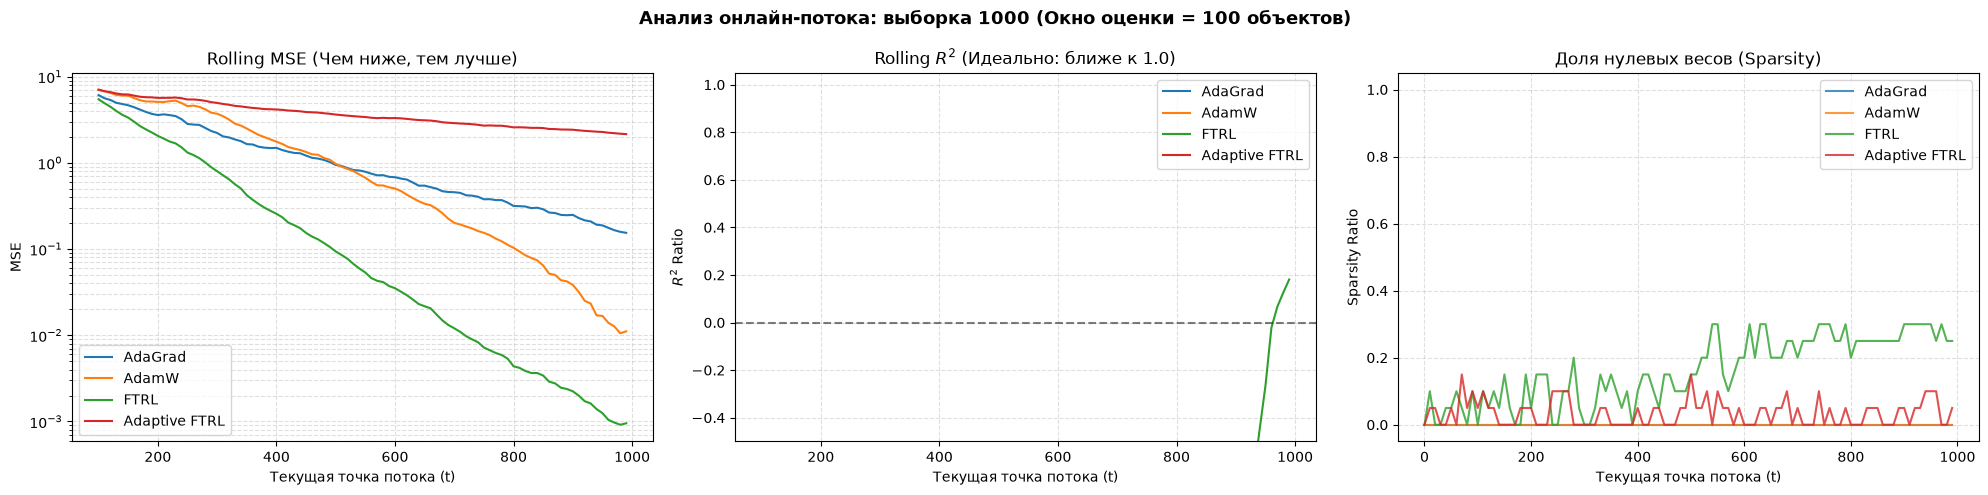

Запуск потока для выборки: 3000 объектов

Расчет скользящих метрик с окном в 300 объектов...

ФИНАЛЬНЫЕ МЕТРИКИ НА ПОСЛЕДНЕМ ОКНЕ (300 об.) ДЛЯ РАЗМЕРА 3000:
Алгоритм        | MSE        | MAE        | R^2 (Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0119     | 0.0725     | -10.6622  
AdamW           | 0.0004     | 0.0158     | 0.5703    
FTRL            | 0.0003     | 0.0124     | 0.6964    
Adaptive FTRL   | 0.4081     | 0.6331     | -400.0960 


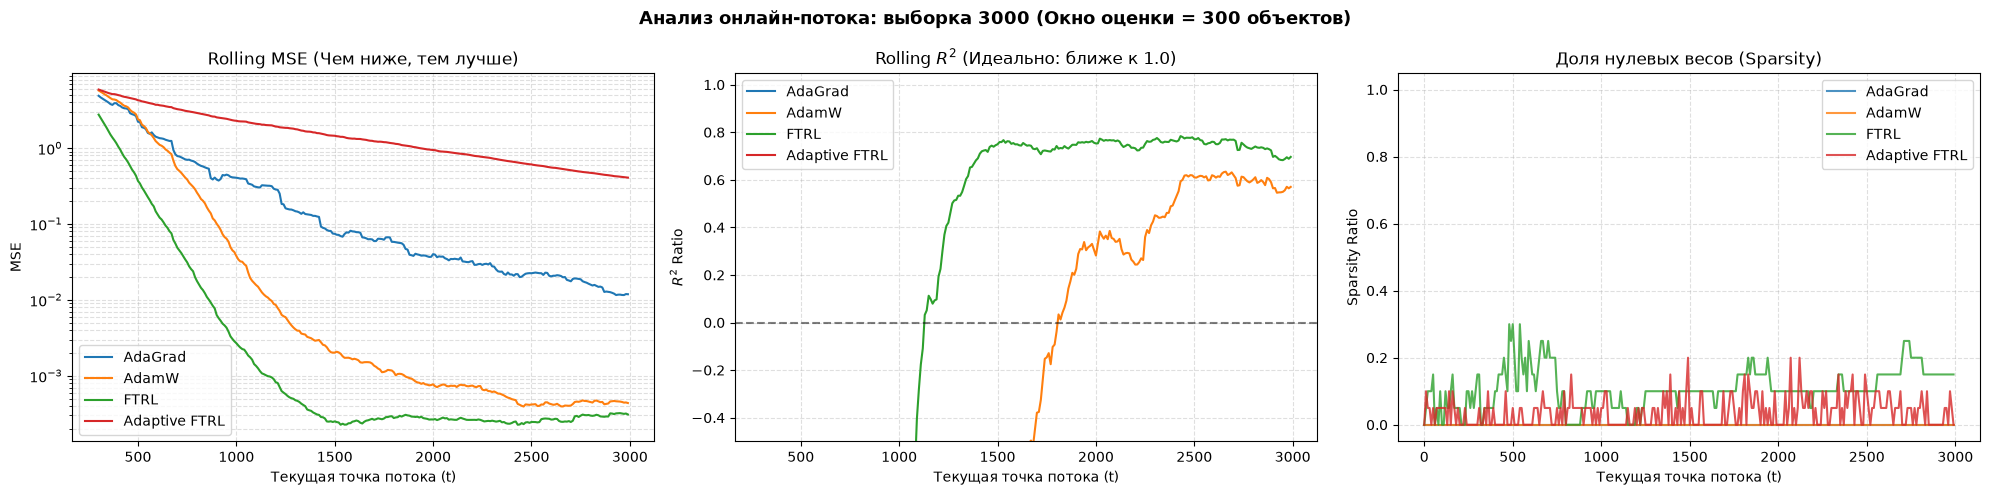

Запуск потока для выборки: 5000 объектов

Расчет скользящих метрик с окном в 500 объектов...

ФИНАЛЬНЫЕ МЕТРИКИ НА ПОСЛЕДНЕМ ОКНЕ (500 об.) ДЛЯ РАЗМЕРА 5000:
Алгоритм        | MSE        | MAE        | R^2 (Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0014     | 0.0234     | -0.1588   
AdamW           | 0.0005     | 0.0147     | 0.5665    
FTRL            | 0.0005     | 0.0124     | 0.6215    
Adaptive FTRL   | 0.0909     | 0.2966     | -72.0835  


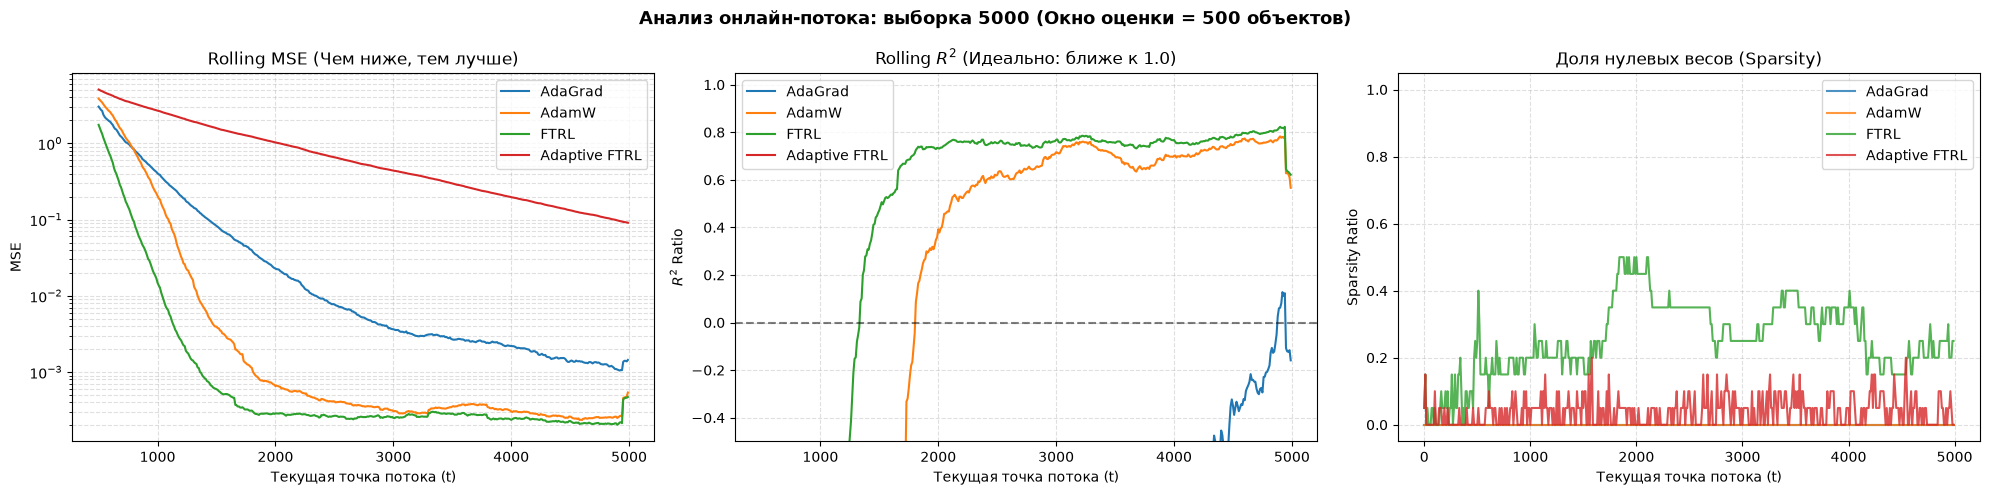

Запуск потока для выборки: 10000 объектов

Расчет скользящих метрик с окном в 1000 объектов...

ФИНАЛЬНЫЕ МЕТРИКИ НА ПОСЛЕДНЕМ ОКНЕ (1000 об.) ДЛЯ РАЗМЕРА 10000:
Алгоритм        | MSE        | MAE        | R^2 (Последнее окно)
-----------------------------------------------------------------
AdaGrad         | 0.0003     | 0.0132     | 0.7205    
AdamW           | 0.0004     | 0.0155     | 0.6263    
FTRL            | 0.0002     | 0.0118     | 0.7827    
Adaptive FTRL   | 0.0026     | 0.0474     | -1.3464   


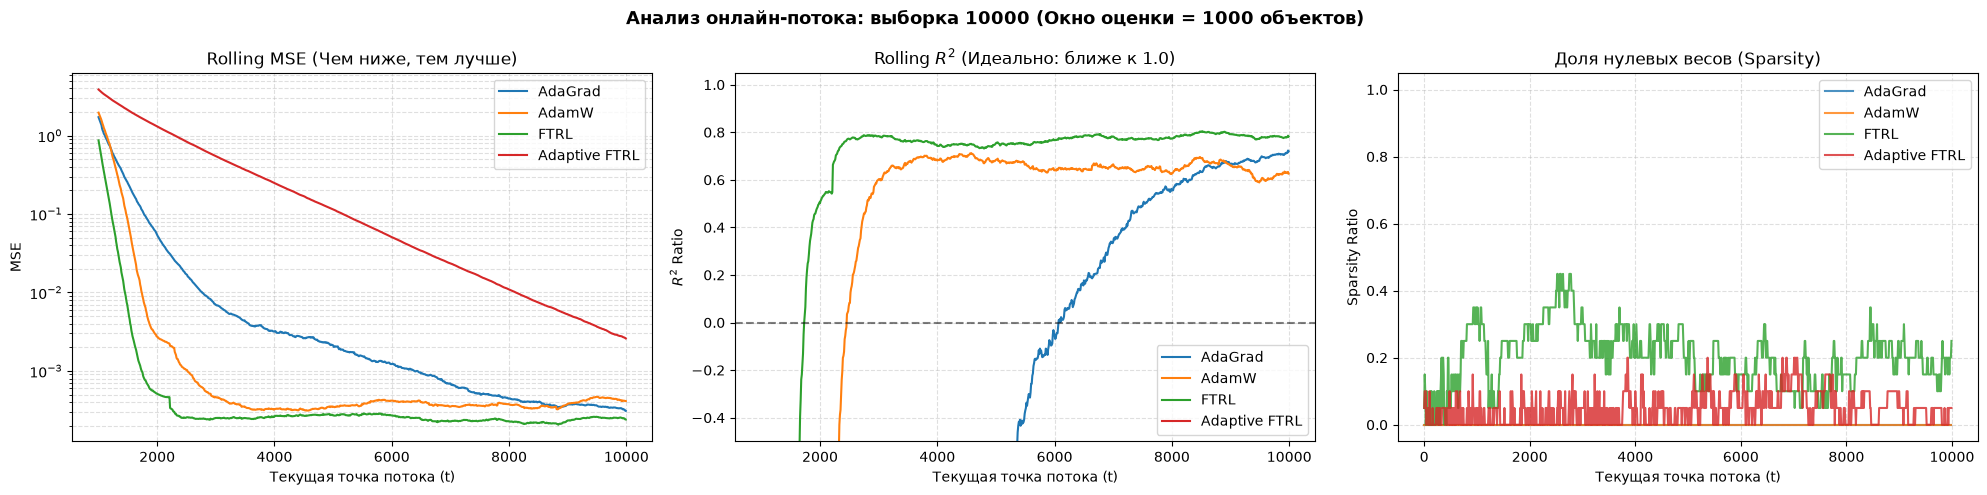

In [9]:
sizes = [1000, 3000, 5000, 10000]
fit_intercept = True
batch_size = 10

for size in sizes:
    print(f"Запуск потока для выборки: {size} объектов")
    X, y = load_data(size)
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0) + 1e-9
    X = (X - X_mean) / X_std
    num_samples, input_dim = X.shape
    
    # Для FTRL определяем эффективную размерность пространства фичей снаружи
    effective_dim = input_dim + 1 if fit_intercept else input_dim
    
    # Инициализация моделей
    adagrad = OnlineAdaGrad(input_dim=input_dim, lr=0.2, fit_intercept=fit_intercept)      
    adamw = OnlineAdamW(input_dim=input_dim, lr=0.05, weight_decay=1e-3, fit_intercept=fit_intercept)
    ftrl_ = FTRL(d=effective_dim, eta=0.1, lambda1=0.1, lambda2=10.0)                     
    ftrl_adaptive = AdaptiveFTRL(d=effective_dim, alpha=0.1, beta=1.0, lambda1=0.1, lambda2=1.0)
    
    # Структура для сбора истории
    names = ["AdaGrad", "AdamW", "FTRL", "Adaptive FTRL"]
    history = {name: {"loss": [], "sparsity": [], "y_true": [], "y_pred": []} for name in names}
    
    # СИМУЛЯЦИЯ чистого онлайн-потока
    for t in range(0, num_samples, batch_size):
        x_batch = X[t : t + batch_size]
        y_batch = y[t : t + batch_size]
        current_b_size = x_batch.shape[0]
        if current_b_size == 0:
            continue
            
        # Тест AdaGrad 
        y_pred_adagrad = adagrad.predict(x_batch)
        loss_adagrad = adagrad.update(x_batch, y_batch)
        history["AdaGrad"]["loss"].append(loss_adagrad)
        history["AdaGrad"]["sparsity"].append(np.sum(adagrad.w == 0.0) / len(adagrad.w))
        history["AdaGrad"]["y_true"].extend(y_batch)
        history["AdaGrad"]["y_pred"].extend(y_pred_adagrad.flatten())
        
        # Тест AdamW
        y_pred_adamw = adamw.predict(x_batch)
        loss_adamw = adamw.update(x_batch, y_batch)
        history["AdamW"]["loss"].append(loss_adamw)
        history["AdamW"]["sparsity"].append(np.sum(adamw.w == 0.0) / len(adamw.w))
        history["AdamW"]["y_true"].extend(y_batch)
        history["AdamW"]["y_pred"].extend(y_pred_adamw.flatten())
        
        # Матрица для FTRL-семейства
        if fit_intercept:
            ones = np.ones((current_b_size, 1))
            x_ftrl_matrix = np.hstack([x_batch, ones])
        else:
            x_ftrl_matrix = x_batch
            
        # Тест FTRL
        y_pred_v = np.dot(x_ftrl_matrix, ftrl_.w)
        error_v = y_pred_v - y_batch
        loss_v = 0.5 * np.mean(error_v ** 2)
        grad_v = np.dot(x_ftrl_matrix.T, error_v) / current_b_size
        ftrl_.update(grad_v) 
        history["FTRL"]["loss"].append(loss_v)
        history["FTRL"]["sparsity"].append(np.sum(ftrl_.w == 0.0) / len(ftrl_.w))
        history["FTRL"]["y_true"].extend(y_batch)
        history["FTRL"]["y_pred"].extend(y_pred_v.flatten())
        
        # Тест Adaptive FTRL
        y_pred_a = np.dot(x_ftrl_matrix, ftrl_adaptive.w)
        error_a = y_pred_a - y_batch
        loss_a = 0.5 * np.mean(error_a ** 2)
        grad_a = np.dot(x_ftrl_matrix.T, error_a) / current_b_size
        ftrl_adaptive.update(grad_a)
        history["Adaptive FTRL"]["loss"].append(loss_a)
        history["Adaptive FTRL"]["sparsity"].append(np.sum(ftrl_adaptive.w == 0.0) / len(ftrl_adaptive.w))
        history["Adaptive FTRL"]["y_true"].extend(y_batch)
        history["Adaptive FTRL"]["y_pred"].extend(y_pred_a.flatten())

    # РАСЧЕТ МЕТРИК В СКОЛЬЗЯЩЕМ ОКНЕ
    window_objects = max(100, size // 10) 
    step = max(1, batch_size) 

    print(f"\nРасчет скользящих метрик с окном в {window_objects} объектов...")

    rolling_metrics = {name: {"steps": [], "mse": [], "r2": []} for name in names}

    for name in names:
        y_true_arr = np.array(history[name]["y_true"])
        y_pred_arr = np.array(history[name]["y_pred"])
        n_total = len(y_true_arr)
        global_mean = np.mean(y_true_arr)
        
        for i in range(window_objects, n_total, step):
            yt_win = y_true_arr[i - window_objects : i]
            yp_win = y_pred_arr[i - window_objects : i]
            
            mse_win = np.mean((yt_win - yp_win) ** 2)
            
            ss_res = np.sum((yt_win - yp_win) ** 2)
            ss_tot = np.sum((yt_win - global_mean) ** 2)
            r2_win = 1.0 - (ss_res / (ss_tot + 1e-9))
            
            rolling_metrics[name]["steps"].append(i)
            rolling_metrics[name]["mse"].append(mse_win)
            rolling_metrics[name]["r2"].append(r2_win)


    print(f"\nФИНАЛЬНЫЕ МЕТРИКИ НА ПОСЛЕДНЕМ ОКНЕ ({window_objects} об.) ДЛЯ РАЗМЕРА {size}:")
    print(f"{'Алгоритм':<15} | {'MSE':<10} | {'MAE':<10} | {'R^2 (Последнее окно)':<10}")
    print("-" * 65)
    for name in names:
        last_mse = rolling_metrics[name]["mse"][-1]
        last_r2 = rolling_metrics[name]["r2"][-1]
        # MAE посчитаем точечно для вывода
        last_mae = np.mean(np.abs(np.array(history[name]["y_true"])[-window_objects:] - np.array(history[name]["y_pred"])[-window_objects:]))
        print(f"{name:<15} | {last_mse:<10.4f} | {last_mae:<10.4f} | {last_r2:<10.4f}")

    # ВИЗУАЛИЗАЦИЯ
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Анализ онлайн-потока: выборка {size} (Окно оценки = {window_objects} объектов)", fontsize=13, fontweight='bold')
    
    for name in names:
        steps = np.array(rolling_metrics[name]["steps"])
        # График Rolling MSE
        ax1.plot(steps, rolling_metrics[name]["mse"], label=f"{name}")
        # График Rolling R^2
        ax2.plot(steps, rolling_metrics[name]["r2"], label=f"{name}")
        # График Sparsity (из оригинальной истории, приводим к шкале объектов)
        steps_sparsity = np.arange(len(history[name]["sparsity"])) * batch_size
        ax3.plot(steps_sparsity, history[name]["sparsity"], label=name, alpha=0.8)
        
    # Настройка графика 1: MSE
    ax1.set_title("Rolling MSE (Чем ниже, тем лучше)")
    ax1.set_xlabel("Текущая точка потока (t)")
    ax1.set_ylabel("MSE")
    ax1.set_yscale('log') # Логарифмическая шкала идеальна для затухания ошибки
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend()
    
    # Настройка графика 2: R^2
    ax2.set_title("Rolling $R^2$ (Идеально: ближе к 1.0)")
    ax2.set_xlabel("Текущая точка потока (t)")
    ax2.set_ylabel("$R^2$ Ratio")
    # Ограничим снизу разумным пределом, чтобы стартовые -100 не сжали весь график в нитку
    ax2.set_ylim(-0.5, 1.05) 
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.grid(True, ls="--", alpha=0.4)
    ax2.legend()
    
    # Настройка графика 3: Sparsity
    ax3.set_title("Доля нулевых весов (Sparsity)")
    ax3.set_xlabel("Текущая точка потока (t)")
    ax3.set_ylabel("Sparsity Ratio")
    ax3.set_ylim(-0.05, 1.05)
    ax3.grid(True, ls="--", alpha=0.4)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()